In [86]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [87]:
#Loading the Dataset
import pyreadstat

df, meta = pyreadstat.read_sav('track_cycle.sav')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1665, 80)


In [88]:
# Previewing the Data
print("First 5 rows:")
df.head()

First 5 rows:


,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1.0,0.0,1.0,0.0,29.0,27.33,17.0,12.0,12.0,...,9.0,NaN,NaN,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nfp8122,3.0,0.0,1.0,0.0,29.0,NaN,15.0,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nfp8122,4.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nfp8122,5.0,0.0,1.0,0.0,28.0,NaN,16.0,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
#Checking all colomn names
print("\nColumns:")
print(df.columns.tolist())



Columns:
['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Schoolyears', 'SchoolyearsM', '

In [90]:
#Checking missing values in the dataset
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ClientID                   0
CycleNumber                0
Group                      0
CycleWithPeakorNot         0
ReproductiveCategory       0
                        ... 
NextpregM               1524
Spousesame              1523
SpousesameM             1523
Timeattemptpreg         1523
BMI                     1534
Length: 80, dtype: int64


In [91]:
# Analysing Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

                            Missing Count  Percentage
MensesScoreDay14                     1664        99.9
MensesScoreDay15                     1664        99.9
MensesScoreDay12                     1664        99.9
MensesScoreDay13                     1664        99.9
MensesScoreDay11                     1663        99.9
...                                   ...         ...
MensesScoreDayTwo                       4         0.2
TotalMensesScore                        4         0.2
NumberofDaysofIntercourse               1         0.1
TotalFertilityFormula                   2         0.1
IntercourseInFertileWindow              1         0.1

[70 rows x 2 columns]


In [92]:
#Categorizing missing values
print("Columns with >50% missing:")
print(missing_df[missing_df['Percentage'] > 50].index.tolist())

print("\nColumns with 5-50% missing:")
print(missing_df[(missing_df['Percentage'] >= 5) & (missing_df['Percentage'] <= 50)].index.tolist())

print("\nColumns with <5% missing:")
print(missing_df[missing_df['Percentage'] < 5].index.tolist())

Columns with >50% missing:
['MensesScoreDay14', 'MensesScoreDay15', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay11', 'MensesScoreDayTen', 'Wedding', 'MensesScoreDayNine', 'Prevmethod', 'Methoddate', 'Girls', 'Boys', 'MensesScoreDayEight', 'LivingkidsM', 'IntercourseDuringUnusBleed', 'PhasesBleeding', 'MeanBleedingIntensity', 'BMI', 'Yearsmarried', 'Weight', 'Height', 'SchoolyearsM', 'Schoolyears', 'Miscarriages', 'IncomeM', 'MedvitsM', 'Abortions', 'MeanCycleLength', 'Ethnicity', 'Religion', 'Numberpreg', 'Livingkids', 'Reprocate', 'Age', 'MeanMensesLength', 'MaristatusM', 'AgeM', 'Maristatus', 'Timeattemptpreg', 'Breastfeeding', 'Nextpreg', 'Whychart', 'NextpregM', 'ReligionM', 'EthnicityM', 'Medvits', 'Method', 'Spousesame', 'SpousesameM', 'OccupationM', 'MensesScoreDaySeven', 'MensesScoreDaySix']

Columns with 5-50% missing:
['MensesScoreDayFive', 'FirstDayofHigh', 'LengthofLutealPhase', 'EstimatedDayofOvulation', 'MensesScoreDayFour']

Columns with <5% missing:
['TotalDa

In [93]:
# Dropping columns with >50% missing
cols_to_drop = missing_df[missing_df['Percentage'] > 50].index.tolist()
df = df.drop(columns=cols_to_drop)
print("Shape after dropping high-missing columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping high-missing columns: (1665, 28)
Remaining columns: ['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries']


In [94]:
# Filling remaining missing values with median
cols_to_fill = df.columns[df.isnull().any()].tolist()
print("Columns with remaining missing values:", cols_to_fill)

for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after filling:")
print(df.isnull().sum().sum(), "missing values remaining")

Columns with remaining missing values: ['EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding']

Missing values after filling:
0 missing values remaining


In [95]:
# Checking and removing duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 13
Shape after removing duplicates: (1652, 28)


In [96]:
#Checking for outliers in key columns
key_cols = ['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'LengthofMenses']

for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (lower={lower:.1f}, upper={upper:.1f})")

LengthofCycle: 73 outliers (lower=21.0, upper=37.0)
EstimatedDayofOvulation: 44 outliers (lower=8.0, upper=24.0)
LengthofLutealPhase: 97 outliers (lower=9.0, upper=17.0)
LengthofMenses: 6 outliers (lower=1.0, upper=9.0)


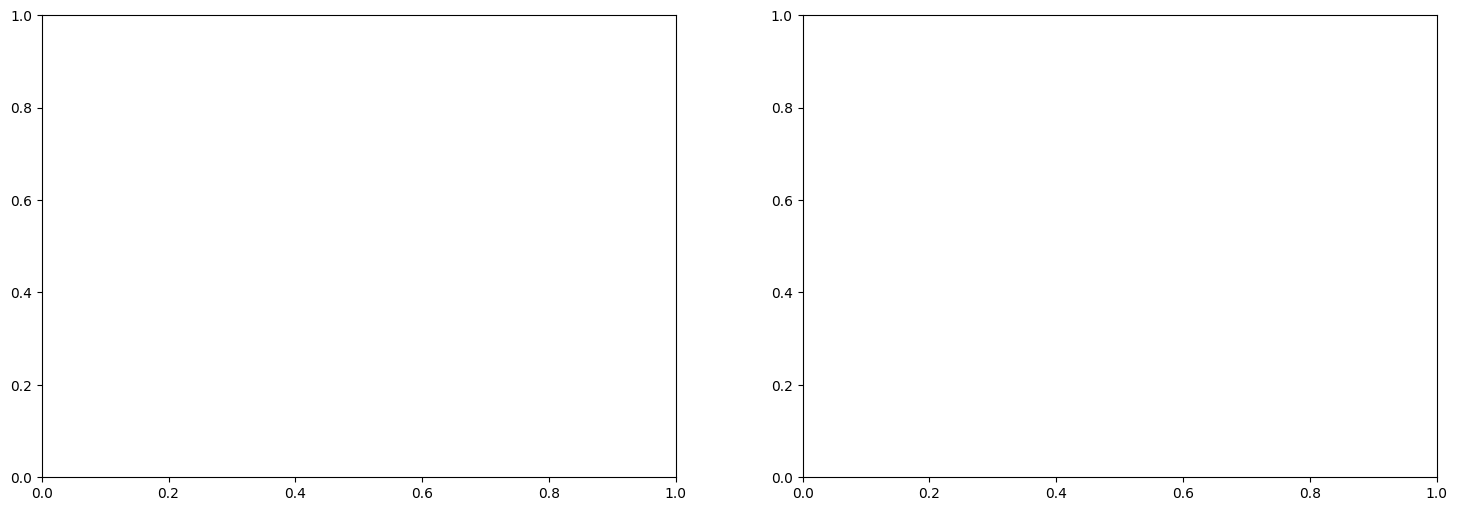

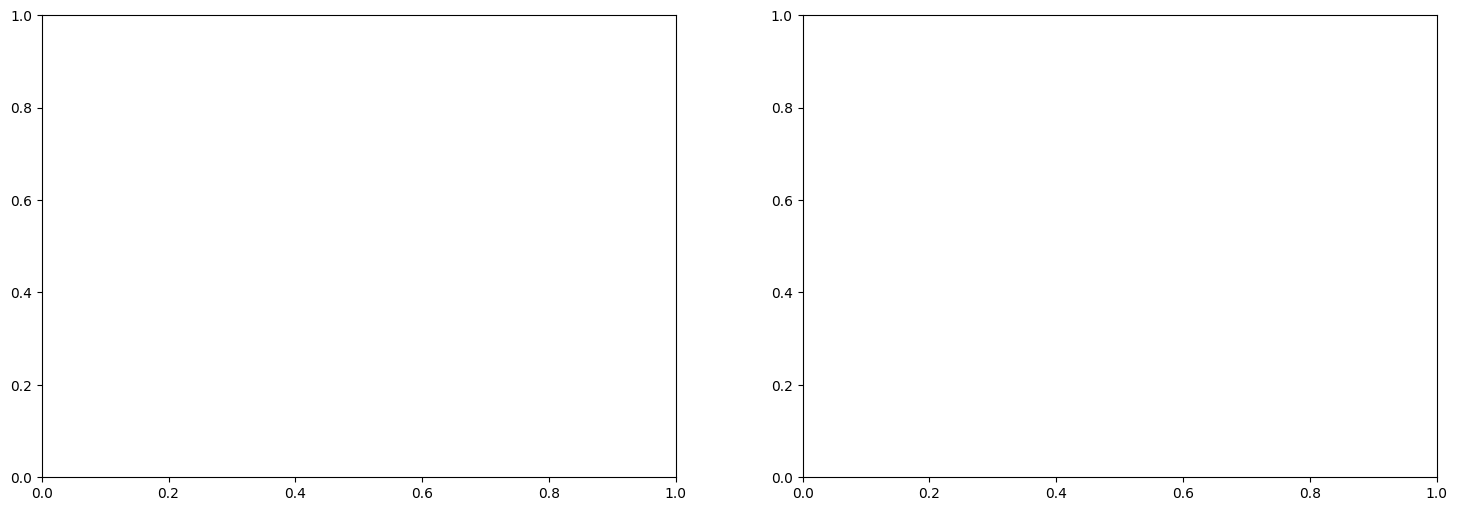

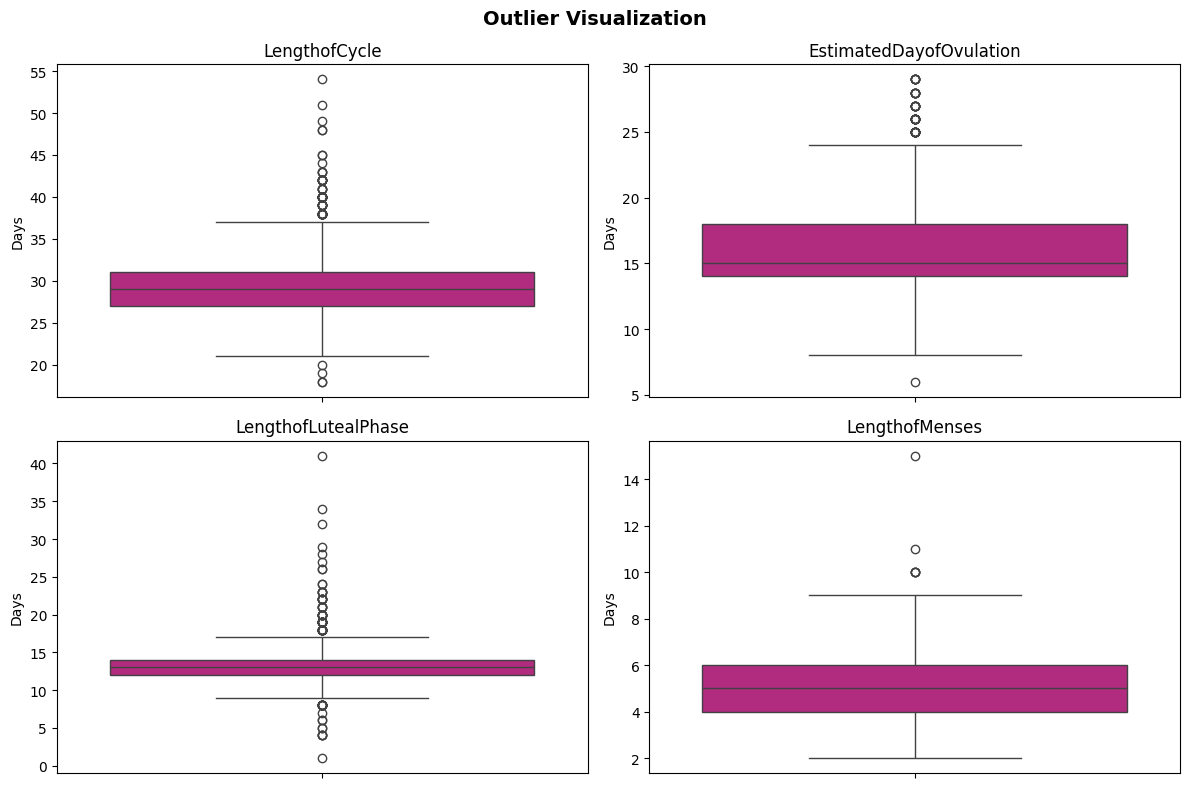

In [97]:
# Visualizing the outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

key_cols = ['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'LengthofMenses']

for ax, col in zip(axes.flatten(), key_cols):
    sns.boxplot(y=df[col], ax=ax, color='mediumvioletred')
    ax.set_title(col)
    ax.set_ylabel('Days')

plt.suptitle('Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
# Removing unrealistic outliers
before = df.shape[0]

# Removing unrealistic menses length
df = df[df['LengthofMenses'] <= 9]

# Removing unrealistic luteal phase
df = df[df['LengthofLutealPhase'] >= 2]

after = df.shape[0]
print(f"Rows removed: {before - after}")
print(f"Shape after removing outliers: {df.shape}")

Rows removed: 7
Shape after removing outliers: (1645, 28)


In [99]:
# Checking data types
print("Data Types:")
print(df.dtypes)

Data Types:
ClientID                       object
CycleNumber                   float64
Group                         float64
CycleWithPeakorNot            float64
ReproductiveCategory          float64
LengthofCycle                 float64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
MensesScoreDayFive            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
Medvitexplain                  object
Gynosurgeries                  object


In [100]:
# Inspecting object columns
obj_cols = ['Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries']
for col in obj_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())


Medvitexplain unique values:
Medvitexplain
                                                                                 1544
Multivitamin                                                                       18
Prenatal vitamin                                                                    4
Vitamin                                                                             2
prenatal vitamins                                                                   2
                                                                                 ... 
Iron supplement and progesterone from peak day plus 3 to the end of the cycle       1
daily vitamin                                                                       1
multi vitamin                                                                       1
benzaclin - acne topical treatment                                                  1
Multi-Vitamin                                                                       1
Name: coun

In [101]:
# Dropping irrelevant text columns
df = df.drop(columns=['Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries'])
print("Shape after dropping text columns:", df.shape)

Shape after dropping text columns: (1645, 24)


In [102]:
#Final cleaning check
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Shape: (1645, 24)

Missing values: 0

Duplicates: 0

Data types:
ClientID                       object
CycleNumber                   float64
Group                         float64
CycleWithPeakorNot            float64
ReproductiveCategory          float64
LengthofCycle                 float64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
MensesScoreDayFive            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
dtype: object


In [103]:
#Saving cleaned dataset 
df.to_csv('cycle_data_cleaned.csv', index=False)
print("Cleaned dataset saved as cycle_data_cleaned.csv")
print("Shape:", df.shape)

Cleaned dataset saved as cycle_data_cleaned.csv
Shape: (1645, 24)


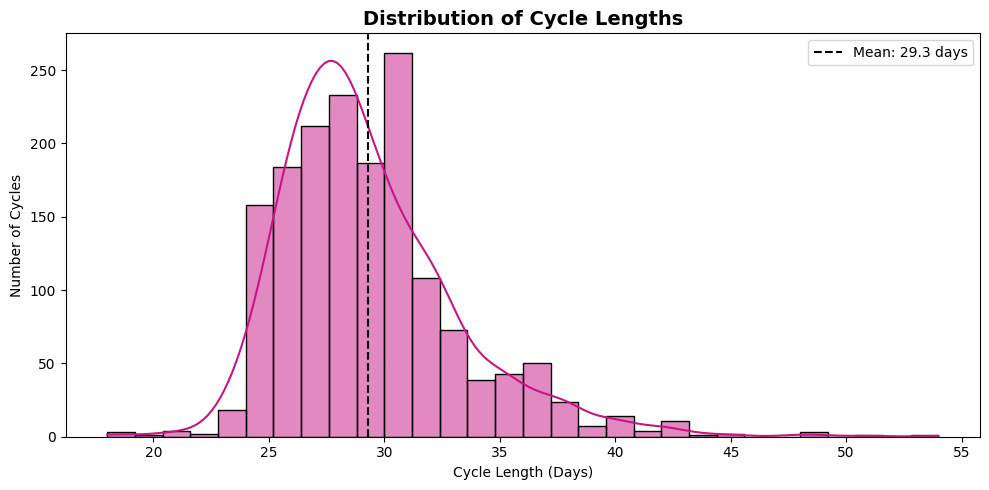

In [104]:
# Distribution of Cycle Lengths(Our key target variable)
plt.figure(figsize=(10, 5))
sns.histplot(df['LengthofCycle'], bins=30, kde=True, color='mediumvioletred')
plt.title('Distribution of Cycle Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Cycle Length (Days)')
plt.ylabel('Number of Cycles')
plt.axvline(df['LengthofCycle'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofCycle"].mean():.1f} days')
plt.legend()
plt.tight_layout()
plt.show()

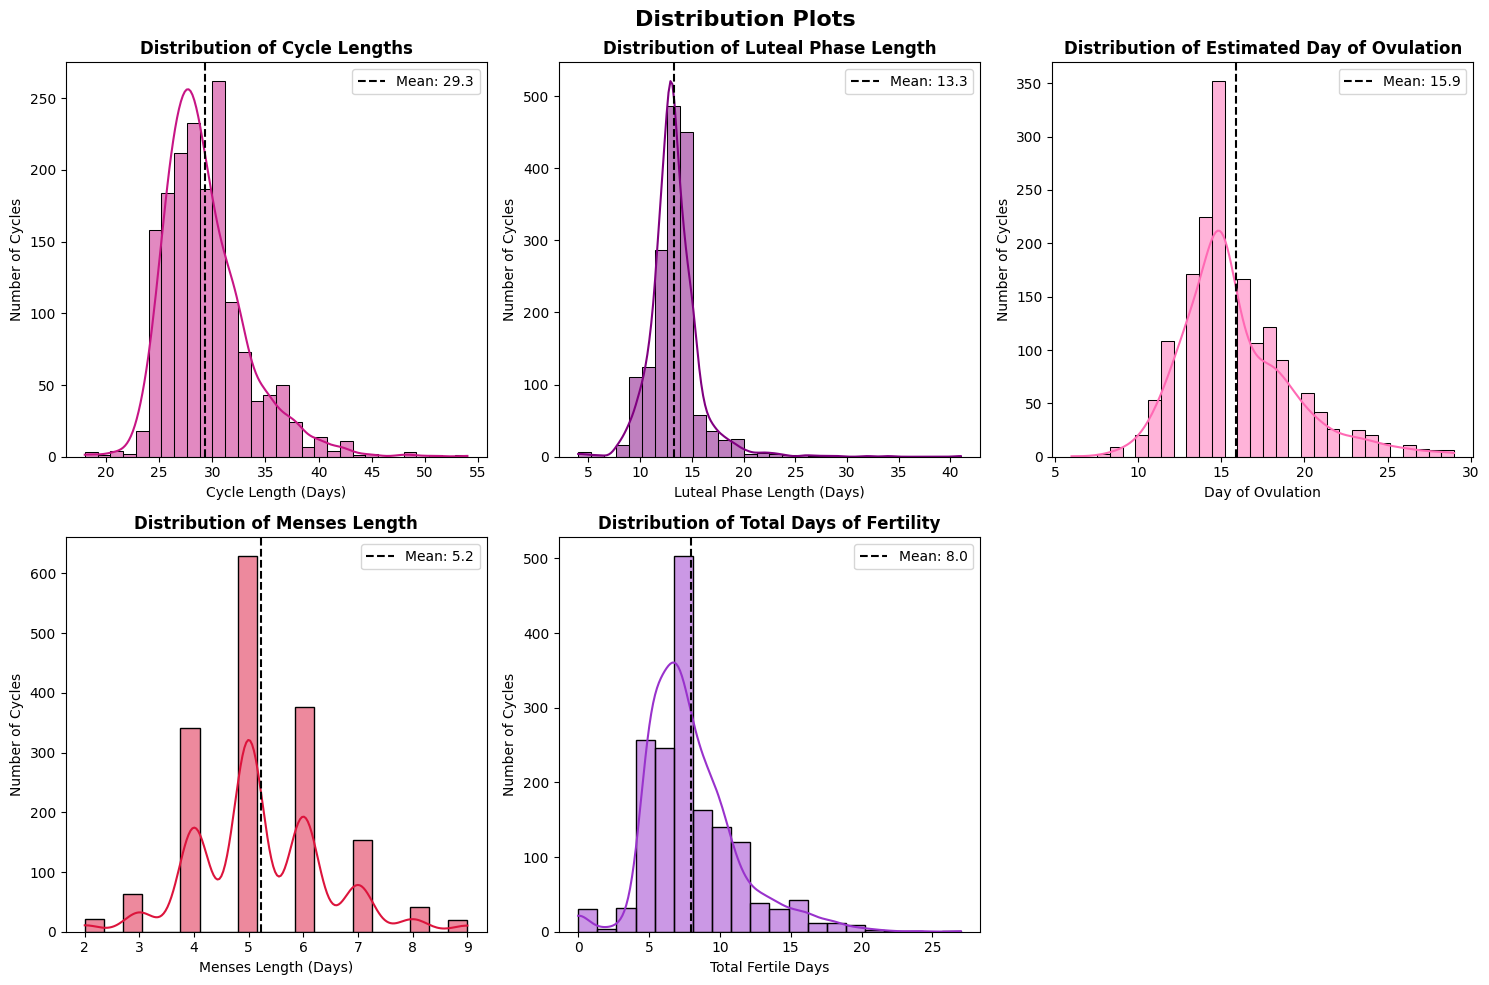

In [105]:
# DISTRIBUTION PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length
sns.histplot(df['LengthofCycle'], bins=30, kde=True, color='mediumvioletred', ax=axes[0,0])
axes[0,0].set_title('Distribution of Cycle Lengths', fontweight='bold')
axes[0,0].set_xlabel('Cycle Length (Days)')
axes[0,0].set_ylabel('Number of Cycles')
axes[0,0].axvline(df['LengthofCycle'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofCycle"].mean():.1f}')
axes[0,0].legend()

# Luteal Phase
sns.histplot(df['LengthofLutealPhase'], bins=30, kde=True, color='purple', ax=axes[0,1])
axes[0,1].set_title('Distribution of Luteal Phase Length', fontweight='bold')
axes[0,1].set_xlabel('Luteal Phase Length (Days)')
axes[0,1].set_ylabel('Number of Cycles')
axes[0,1].axvline(df['LengthofLutealPhase'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofLutealPhase"].mean():.1f}')
axes[0,1].legend()

# Ovulation Day
sns.histplot(df['EstimatedDayofOvulation'], bins=30, kde=True, color='hotpink', ax=axes[0,2])
axes[0,2].set_title('Distribution of Estimated Day of Ovulation', fontweight='bold')
axes[0,2].set_xlabel('Day of Ovulation')
axes[0,2].set_ylabel('Number of Cycles')
axes[0,2].axvline(df['EstimatedDayofOvulation'].mean(), color='black', linestyle='--', label=f'Mean: {df["EstimatedDayofOvulation"].mean():.1f}')
axes[0,2].legend()

# Menses Length
sns.histplot(df['LengthofMenses'], bins=20, kde=True, color='crimson', ax=axes[1,0])
axes[1,0].set_title('Distribution of Menses Length', fontweight='bold')
axes[1,0].set_xlabel('Menses Length (Days)')
axes[1,0].set_ylabel('Number of Cycles')
axes[1,0].axvline(df['LengthofMenses'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofMenses"].mean():.1f}')
axes[1,0].legend()

# Total Days of Fertility
sns.histplot(df['TotalDaysofFertility'], bins=20, kde=True, color='darkorchid', ax=axes[1,1])
axes[1,1].set_title('Distribution of Total Days of Fertility', fontweight='bold')
axes[1,1].set_xlabel('Total Fertile Days')
axes[1,1].set_ylabel('Number of Cycles')
axes[1,1].axvline(df['TotalDaysofFertility'].mean(), color='black', linestyle='--', label=f'Mean: {df["TotalDaysofFertility"].mean():.1f}')
axes[1,1].legend()

# Hide empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Distribution Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [106]:
#BOX PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='LengthofCycle', data=df, color='mediumvioletred', ax=axes[0,0])
axes[0,0].set_title('Cycle Length by Reproductive Category', fontweight='bold')
axes[0,0].set_xlabel('Reproductive Category')
axes[0,0].set_ylabel('Cycle Length (Days)')

# Cycle Length by CycleWithPeakorNot
sns.boxplot(x='CycleWithPeakorNot', y='LengthofCycle', data=df, color='purple', ax=axes[0,1])
axes[0,1].set_title('Cycle Length by Cycle With Peak or Not', fontweight='bold')
axes[0,1].set_xlabel('Cycle With Peak (0=No, 1=Yes)')
axes[0,1].set_ylabel('Cycle Length (Days)')

# Luteal Phase by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='LengthofLutealPhase', data=df, color='hotpink', ax=axes[0,2])
axes[0,2].set_title('Luteal Phase by Reproductive Category', fontweight='bold')
axes[0,2].set_xlabel('Reproductive Category')
axes[0,2].set_ylabel('Luteal Phase Length (Days)')

# Menses Length by Group
sns.boxplot(x='Group', y='LengthofMenses', data=df, color='crimson', ax=axes[1,0])
axes[1,0].set_title('Menses Length by Group', fontweight='bold')
axes[1,0].set_xlabel('Group')
axes[1,0].set_ylabel('Menses Length (Days)')

# Ovulation Day by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='EstimatedDayofOvulation', data=df, color='darkorchid', ax=axes[1,1])
axes[1,1].set_title('Ovulation Day by Reproductive Category', fontweight='bold')
axes[1,1].set_xlabel('Reproductive Category')
axes[1,1].set_ylabel('Day of Ovulation')

# Hidng empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

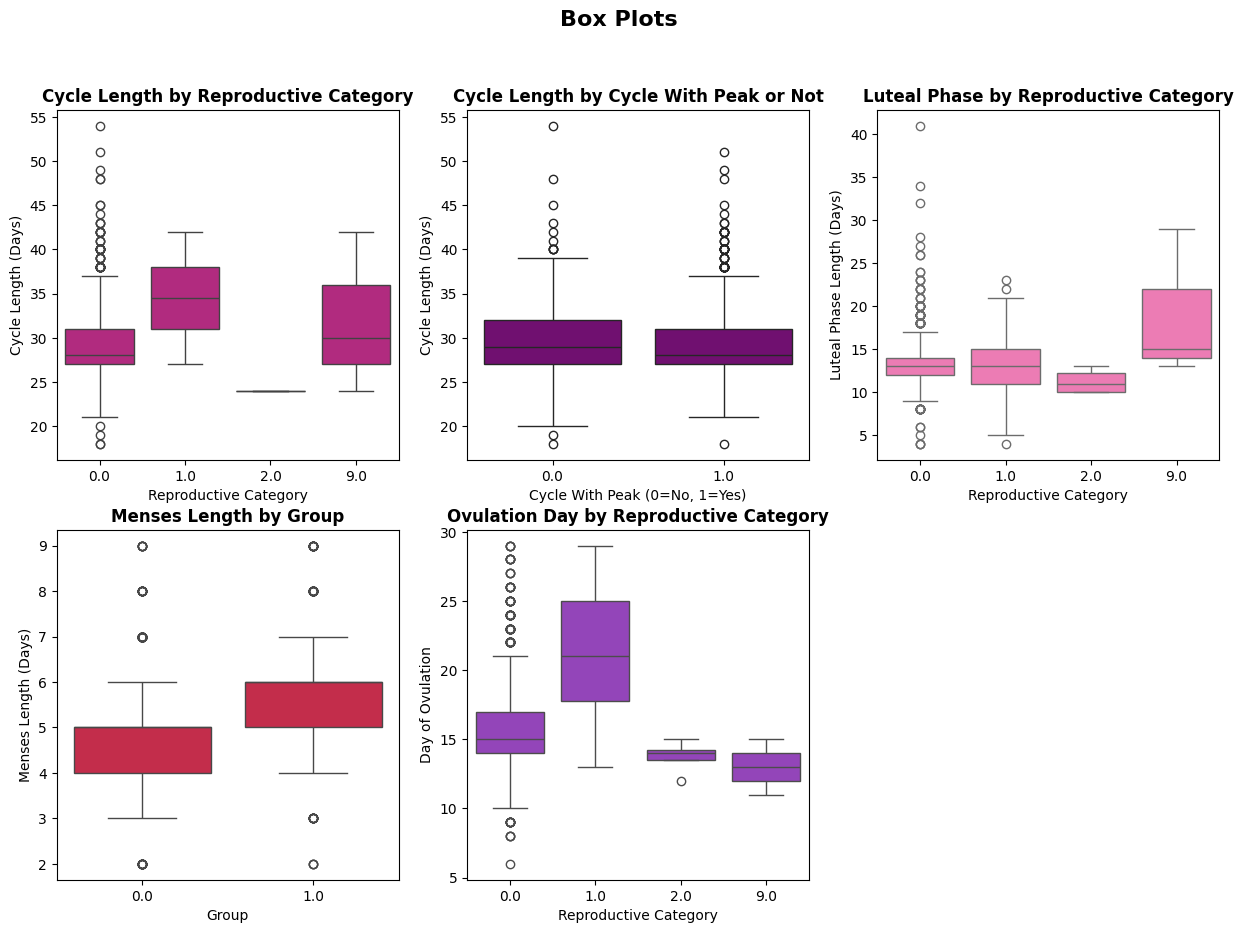

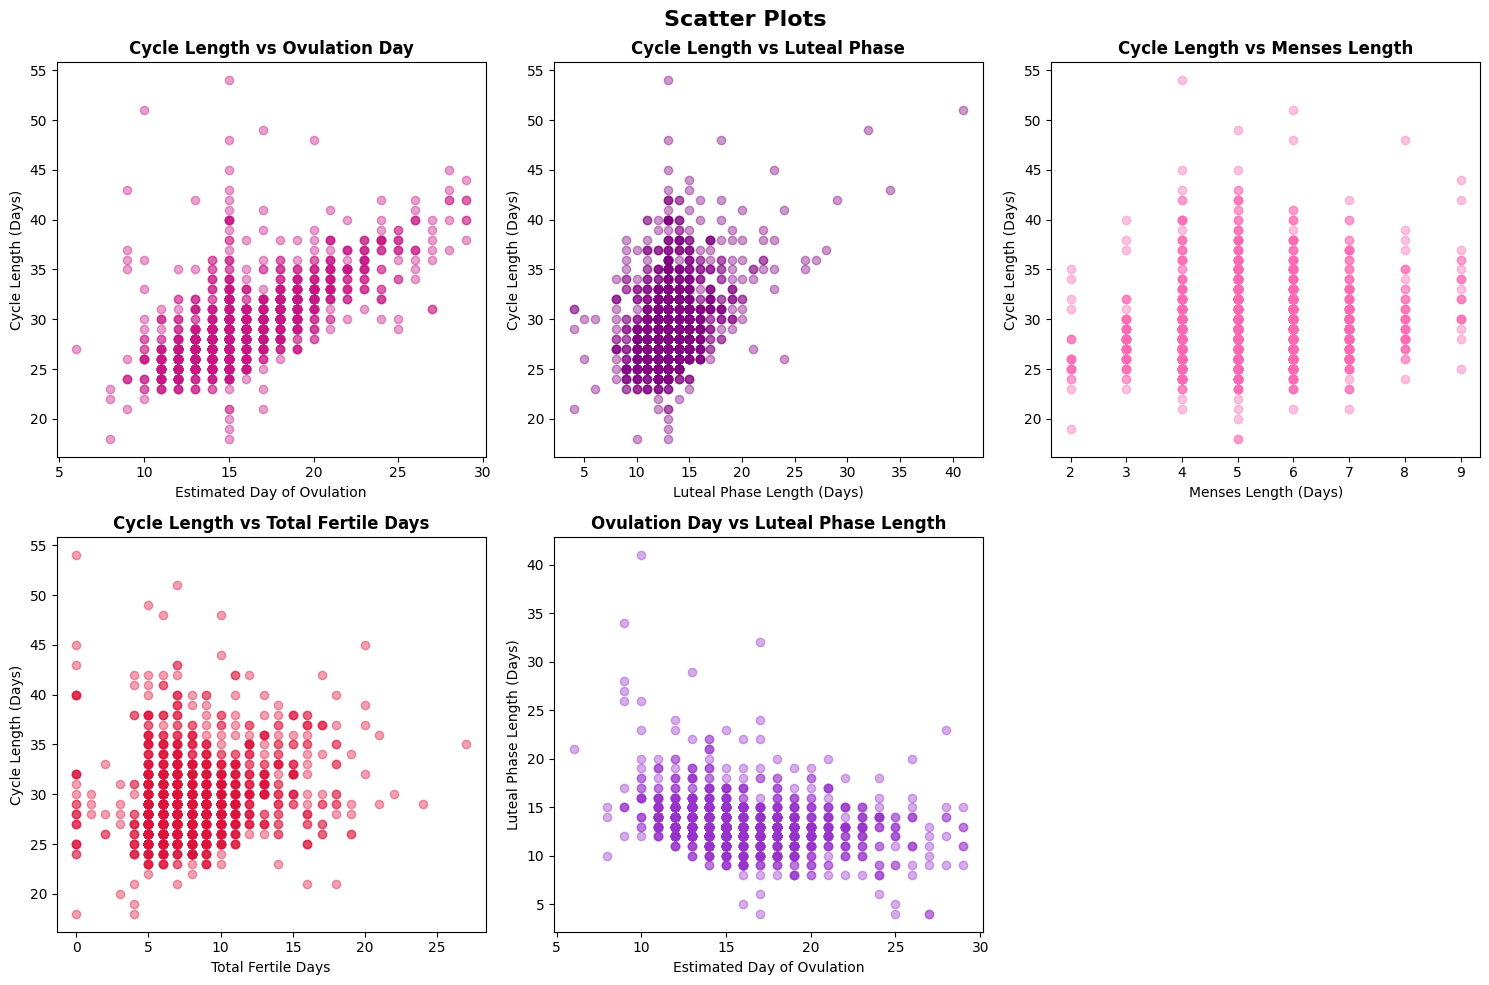

In [107]:
# SCATTER PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length vs Ovulation Day
axes[0,0].scatter(df['EstimatedDayofOvulation'], df['LengthofCycle'], color='mediumvioletred', alpha=0.4)
axes[0,0].set_title('Cycle Length vs Ovulation Day', fontweight='bold')
axes[0,0].set_xlabel('Estimated Day of Ovulation')
axes[0,0].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Luteal Phase
axes[0,1].scatter(df['LengthofLutealPhase'], df['LengthofCycle'], color='purple', alpha=0.4)
axes[0,1].set_title('Cycle Length vs Luteal Phase', fontweight='bold')
axes[0,1].set_xlabel('Luteal Phase Length (Days)')
axes[0,1].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Menses Length
axes[0,2].scatter(df['LengthofMenses'], df['LengthofCycle'], color='hotpink', alpha=0.4)
axes[0,2].set_title('Cycle Length vs Menses Length', fontweight='bold')
axes[0,2].set_xlabel('Menses Length (Days)')
axes[0,2].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Total Fertile Days
axes[1,0].scatter(df['TotalDaysofFertility'], df['LengthofCycle'], color='crimson', alpha=0.4)
axes[1,0].set_title('Cycle Length vs Total Fertile Days', fontweight='bold')
axes[1,0].set_xlabel('Total Fertile Days')
axes[1,0].set_ylabel('Cycle Length (Days)')

# Ovulation Day vs Luteal Phase
axes[1,1].scatter(df['EstimatedDayofOvulation'], df['LengthofLutealPhase'], color='darkorchid', alpha=0.4)
axes[1,1].set_title('Ovulation Day vs Luteal Phase Length', fontweight='bold')
axes[1,1].set_xlabel('Estimated Day of Ovulation')
axes[1,1].set_ylabel('Luteal Phase Length (Days)')

# Hide empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Scatter Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

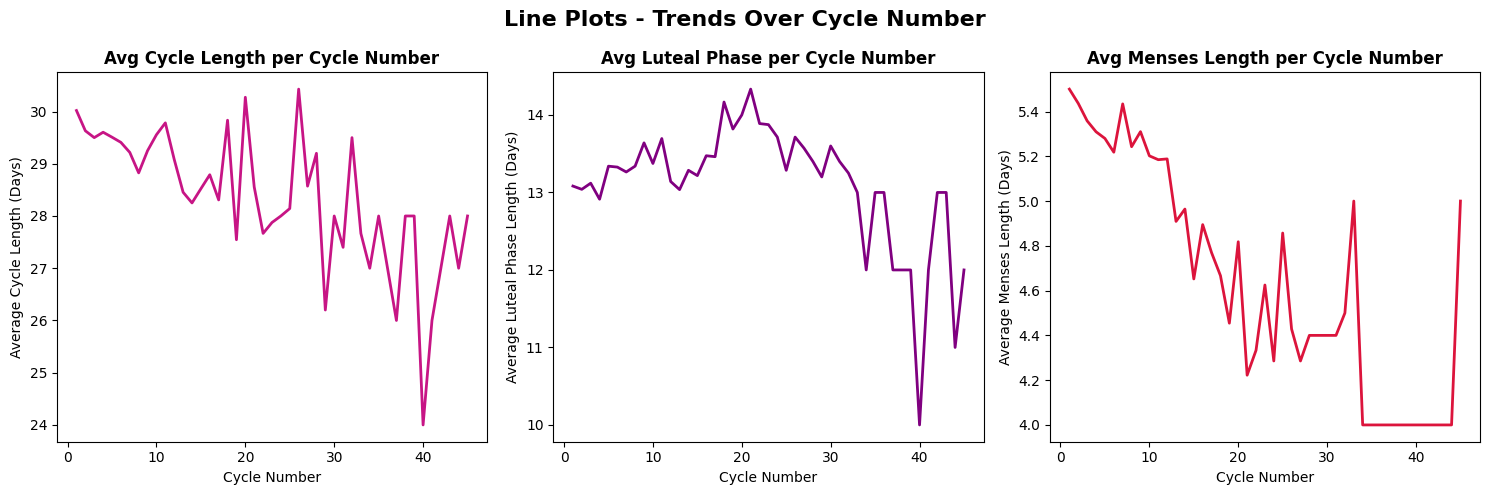

In [108]:
#LINE PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Average Cycle Length per Cycle Number
cycle_avg = df.groupby('CycleNumber')['LengthofCycle'].mean()
axes[0].plot(cycle_avg.index, cycle_avg.values, color='mediumvioletred', linewidth=2)
axes[0].set_title('Avg Cycle Length per Cycle Number', fontweight='bold')
axes[0].set_xlabel('Cycle Number')
axes[0].set_ylabel('Average Cycle Length (Days)')

# Average Luteal Phase per Cycle Number
luteal_avg = df.groupby('CycleNumber')['LengthofLutealPhase'].mean()
axes[1].plot(luteal_avg.index, luteal_avg.values, color='purple', linewidth=2)
axes[1].set_title('Avg Luteal Phase per Cycle Number', fontweight='bold')
axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('Average Luteal Phase Length (Days)')

# Average Menses Length per Cycle Number
menses_avg = df.groupby('CycleNumber')['LengthofMenses'].mean()
axes[2].plot(menses_avg.index, menses_avg.values, color='crimson', linewidth=2)
axes[2].set_title('Avg Menses Length per Cycle Number', fontweight='bold')
axes[2].set_xlabel('Cycle Number')
axes[2].set_ylabel('Average Menses Length (Days)')

plt.suptitle('Line Plots - Trends Over Cycle Number', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

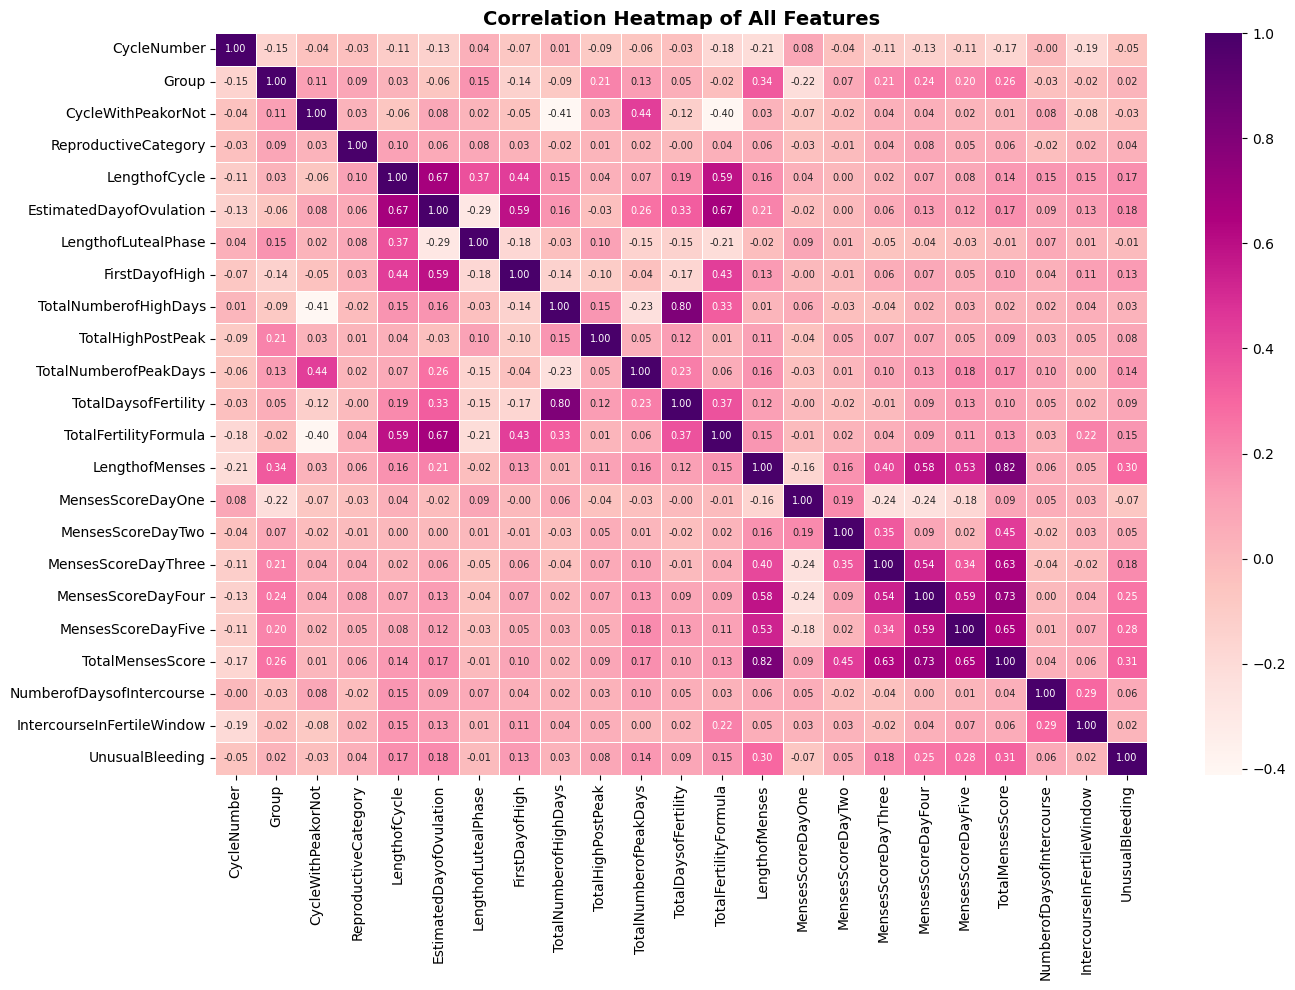

In [109]:
#CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['ClientID']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

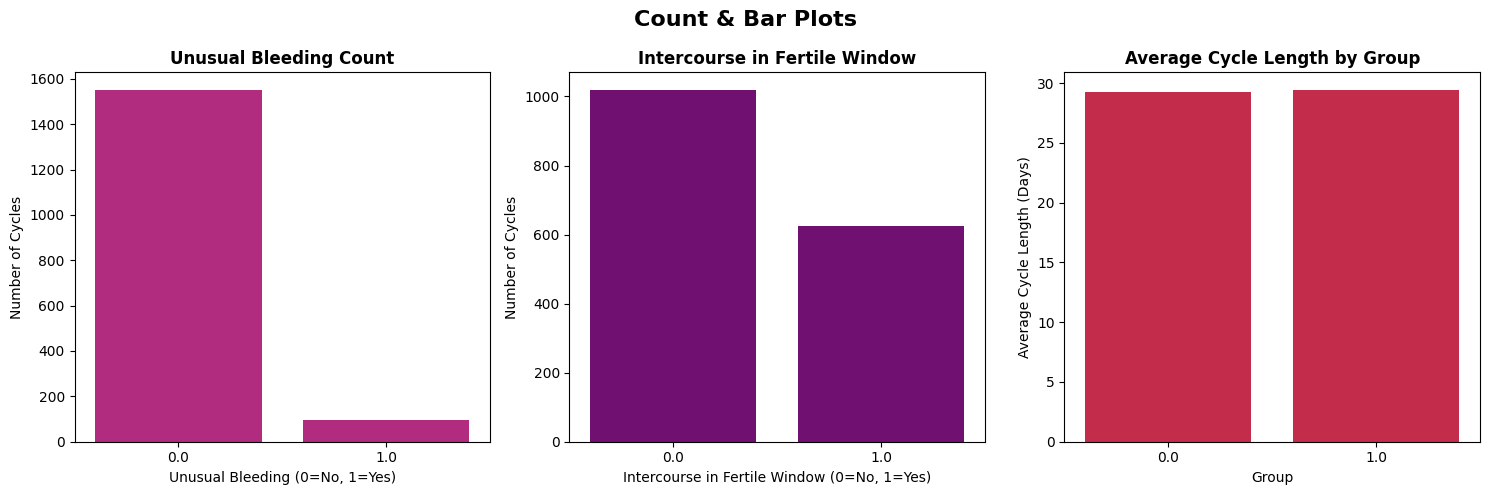

In [110]:
# COUNT & BAR PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Unusual Bleeding Count
sns.countplot(x='UnusualBleeding', data=df, color='mediumvioletred', ax=axes[0])
axes[0].set_title('Unusual Bleeding Count', fontweight='bold')
axes[0].set_xlabel('Unusual Bleeding (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Cycles')

# Intercourse in Fertile Window Count
sns.countplot(x='IntercourseInFertileWindow', data=df, color='purple', ax=axes[1])
axes[1].set_title('Intercourse in Fertile Window', fontweight='bold')
axes[1].set_xlabel('Intercourse in Fertile Window (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Cycles')

# Average Cycle Length by Group
group_avg = df.groupby('Group')['LengthofCycle'].mean().reset_index()
sns.barplot(x='Group', y='LengthofCycle', data=group_avg, color='crimson', ax=axes[2])
axes[2].set_title('Average Cycle Length by Group', fontweight='bold')
axes[2].set_xlabel('Group')
axes[2].set_ylabel('Average Cycle Length (Days)')

plt.suptitle('Count & Bar Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

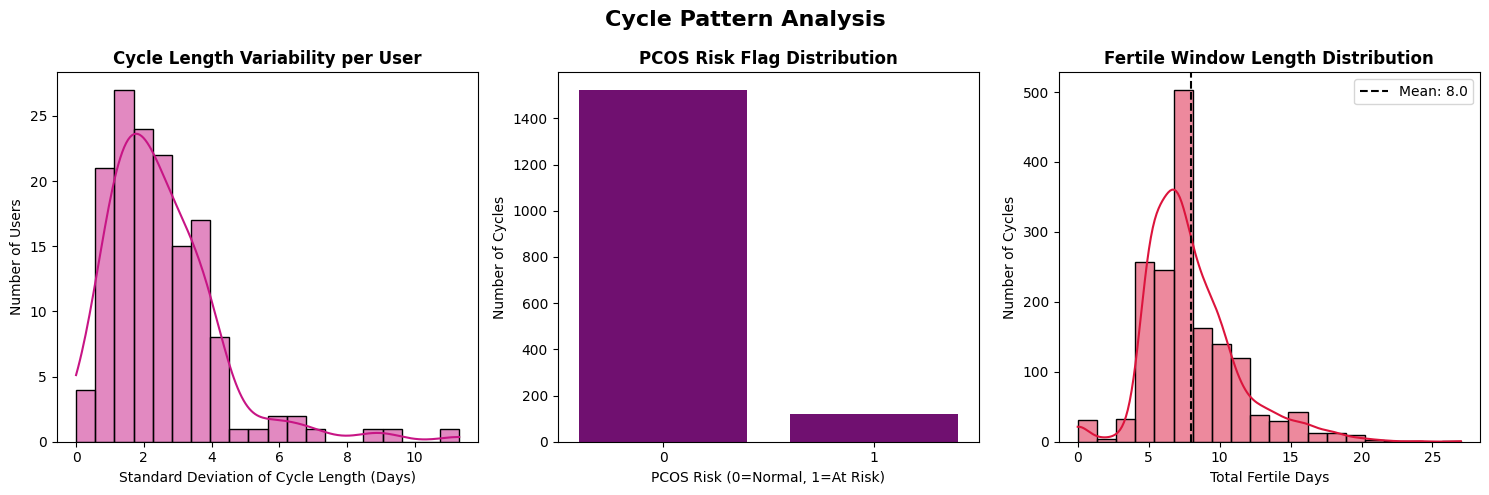

In [111]:
# Cycle Pattern Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cycle Length Variability per User
cycle_std = df.groupby('ClientID')['LengthofCycle'].std().dropna()
sns.histplot(cycle_std, bins=20, kde=True, color='mediumvioletred', ax=axes[0])
axes[0].set_title('Cycle Length Variability per User', fontweight='bold')
axes[0].set_xlabel('Standard Deviation of Cycle Length (Days)')
axes[0].set_ylabel('Number of Users')

# PCOS Risk Flag Distribution
df['PCOS_Risk'] = df['LengthofCycle'].apply(lambda x: 1 if x < 21 or x > 35 else 0)
sns.countplot(x='PCOS_Risk', data=df, color='purple', ax=axes[1])
axes[1].set_title('PCOS Risk Flag Distribution', fontweight='bold')
axes[1].set_xlabel('PCOS Risk (0=Normal, 1=At Risk)')
axes[1].set_ylabel('Number of Cycles')

# Fertile Window Length Distribution
sns.histplot(df['TotalDaysofFertility'], bins=20, kde=True, color='crimson', ax=axes[2])
axes[2].set_title('Fertile Window Length Distribution', fontweight='bold')
axes[2].set_xlabel('Total Fertile Days')
axes[2].set_ylabel('Number of Cycles')
axes[2].axvline(df['TotalDaysofFertility'].mean(), color='black', linestyle='--', label=f'Mean: {df["TotalDaysofFertility"].mean():.1f}')
axes[2].legend()

plt.suptitle('Cycle Pattern Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [112]:
# Feature Engineering
# Sort by user and cycle number first
df = df.sort_values(['ClientID', 'CycleNumber']).reset_index(drop=True)

# Previous cycle lengths
df['PrevCycleLength'] = df.groupby('ClientID')['LengthofCycle'].shift(1)
df['Prev2CycleLength'] = df.groupby('ClientID')['LengthofCycle'].shift(2)
df['Prev3CycleLength'] = df.groupby('ClientID')['LengthofCycle'].shift(3)

# Rolling average of last 3 cycles
df['RollingAvg3'] = df.groupby('ClientID')['LengthofCycle'].transform(lambda x: x.shift(1).rolling(3).mean())

# Cycle variability - std of last 3 cycles
df['CycleVariability'] = df.groupby('ClientID')['LengthofCycle'].transform(lambda x: x.shift(1).rolling(3).std())

# Is irregular flag
df['IsIrregular'] = df['LengthofCycle'].apply(lambda x: 1 if x < 21 or x > 35 else 0)

print("New features added!")
print("Shape:", df.shape)
print("\nNew columns:")
print(df[['ClientID', 'CycleNumber', 'LengthofCycle', 'PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability', 'IsIrregular']].head(10))

New features added!
Shape: (1645, 31)

New columns:
  ClientID  CycleNumber  LengthofCycle  PrevCycleLength  Prev2CycleLength  \
0  nfp8020          1.0           27.0              NaN               NaN   
1  nfp8020          2.0           31.0             27.0               NaN   
2  nfp8020          3.0           27.0             31.0              27.0   
3  nfp8020          4.0           28.0             27.0              31.0   
4  nfp8020          5.0           27.0             28.0              27.0   
5  nfp8020          6.0           27.0             27.0              28.0   
6  nfp8020          7.0           27.0             27.0              27.0   
7  nfp8020          8.0           25.0             27.0              27.0   
8  nfp8020          9.0           24.0             25.0              27.0   
9  nfp8020         10.0           18.0             24.0              25.0   

   Prev3CycleLength  RollingAvg3  CycleVariability  IsIrregular  
0               NaN          NaN  

In [113]:
# Dropping NaN rows created by feature engineering
before = df.shape[0]
df = df.dropna(subset=['PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability'])
after = df.shape[0]

print(f"Rows removed: {before - after}")
print(f"Shape after dropping NaN rows: {df.shape}")

Rows removed: 442
Shape after dropping NaN rows: (1203, 31)


In [114]:
# Feature Selection
feature_cols = [
    'PrevCycleLength',
    'Prev2CycleLength', 
    'Prev3CycleLength',
    'RollingAvg3',
    'CycleVariability',
    'EstimatedDayofOvulation',
    'LengthofLutealPhase',
    'FirstDayofHigh',
    'TotalFertilityFormula',
    'LengthofMenses',
    'IsIrregular',
    'PCOS_Risk'
]

target = 'LengthofCycle'

print("Features selected:", len(feature_cols))
print("Feature columns:", feature_cols)
print("\nTarget:", target)
print("\nFinal dataset shape:", df[feature_cols + [target]].shape)

Features selected: 12
Feature columns: ['PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalFertilityFormula', 'LengthofMenses', 'IsIrregular', 'PCOS_Risk']

Target: LengthofCycle

Final dataset shape: (1203, 13)


In [115]:
#Scale Features
from sklearn.preprocessing import StandardScaler

X = df[feature_cols]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("Features scaled successfully!")
print("\nBefore scaling - PrevCycleLength stats:")
print(X['PrevCycleLength'].describe())
print("\nAfter scaling - PrevCycleLength stats:")
print(X_scaled['PrevCycleLength'].describe())

Features scaled successfully!

Before scaling - PrevCycleLength stats:
count    1203.000000
mean       29.178720
std         3.872401
min        18.000000
25%        27.000000
50%        28.000000
75%        31.000000
max        51.000000
Name: PrevCycleLength, dtype: float64

After scaling - PrevCycleLength stats:
count    1.203000e+03
mean    -4.193561e-16
std      1.000416e+00
min     -2.887968e+00
25%     -5.628617e-01
50%     -3.045165e-01
75%      4.705189e-01
max      5.637422e+00
Name: PrevCycleLength, dtype: float64


In [116]:
# Saving cleaned and engineered dataset
df.to_csv('cycle_data_clean.csv', index=False)
print("Dataset saved as cycle_data_clean.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset saved as cycle_data_clean.csv
Shape: (1203, 31)
Columns: ['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PCOS_Risk', 'PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability', 'IsIrregular']


In [117]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"\n80% training: {len(X_train)} rows")
print(f"20% testing: {len(X_test)} rows")

Training set size: (962, 12)
Testing set size: (241, 12)

80% training: 962 rows
20% testing: 241 rows


In [118]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print(f"MAE:  {lr_mae:.3f}")
print(f"RMSE: {lr_rmse:.3f}")
print(f"R2:   {lr_r2:.3f}")

Linear Regression Results:
MAE:  0.696
RMSE: 1.290
R2:   0.869


In [143]:
# Cross-Validation for Linear Regression
from sklearn.model_selection import cross_val_score
import numpy as np

lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')

print(" Linear Regression : 5-Fold Cross-Validation ")
for i, score in enumerate(lr_cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\nMean CV R²:       {lr_cv_scores.mean():.4f}")
print(f"Std Deviation:    {lr_cv_scores.std():.4f}")
print(f"Min R²:           {lr_cv_scores.min():.4f}")
print(f"Max R²:           {lr_cv_scores.max():.4f}")
print(f"\nTest Set R²:      {lr_r2:.4f}  (for comparison)")


 Linear Regression : 5-Fold Cross-Validation 
  Fold 1: R² = 0.8793
  Fold 2: R² = 0.9189
  Fold 3: R² = 0.7522
  Fold 4: R² = 0.8036
  Fold 5: R² = 0.9203

Mean CV R²:       0.8549
Std Deviation:    0.0665
Min R²:           0.7522
Max R²:           0.9203

Test Set R²:      0.8688  (for comparison)


In [120]:
#Linear Regression Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept (β₀): {lr_model.intercept_:.4f}")
print("\nFeature Coefficients (sorted by importance):")
print(coef_df.to_string(index=False))

Intercept (β₀): 29.1355

Feature Coefficients (sorted by importance):
                Feature  Coefficient
EstimatedDayofOvulation     2.089671
    LengthofLutealPhase     2.073875
  TotalFertilityFormula     0.714139
       Prev3CycleLength     0.284159
              PCOS_Risk     0.278409
            IsIrregular     0.278409
            RollingAvg3     0.169903
         FirstDayofHigh     0.168622
       Prev2CycleLength     0.155065
       CycleVariability    -0.063610
        PrevCycleLength    -0.021775
         LengthofMenses    -0.012453


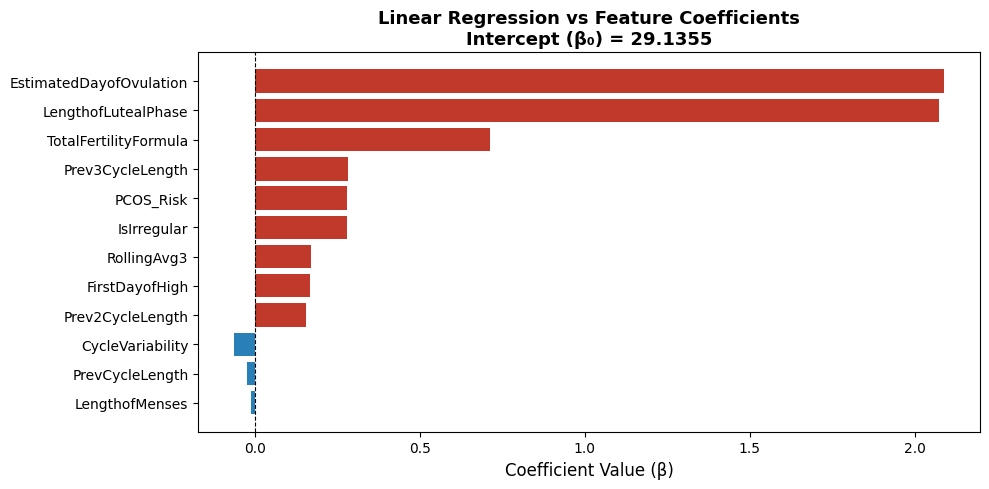

In [121]:
# Linear Regression Coefficients Plot
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#c0392b' if c > 0 else '#2980b9' for c in coef_df['Coefficient']]

ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value (β)', fontsize=12)
ax.set_title('Linear Regression vs Feature Coefficients\n'
             f'Intercept (β₀) = {lr_model.intercept_:.4f}', 
             fontweight='bold', fontsize=13)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

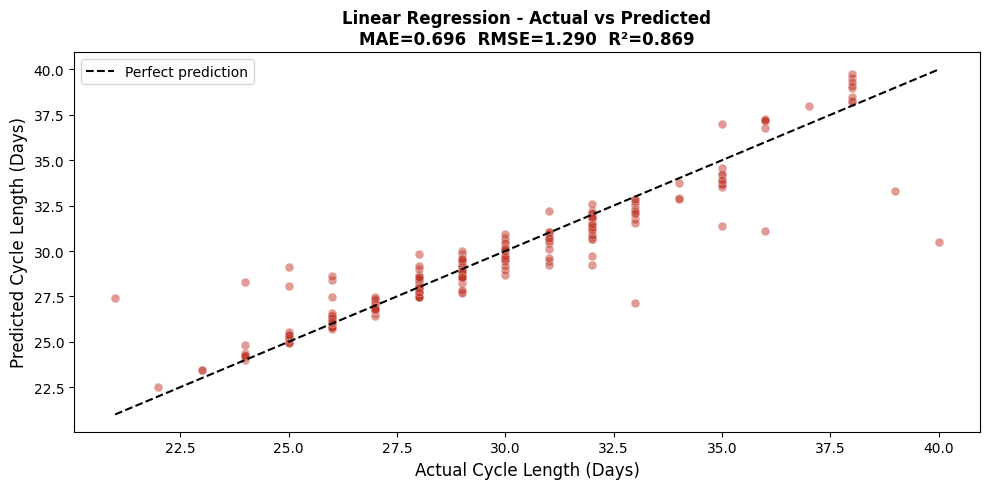

In [122]:
# Linear Regression Actual vs Predicted visualization   
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(y_test, lr_pred, alpha=0.5, color='#c0392b', 
           edgecolors='white', linewidth=0.4, s=40)

min_val = min(y_test.min(), lr_pred.min())
max_val = max(y_test.max(), lr_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', 
        linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual Cycle Length (Days)', fontsize=12)
ax.set_ylabel('Predicted Cycle Length (Days)', fontsize=12)
ax.set_title(f'Linear Regression - Actual vs Predicted\n'
             f'MAE={lr_mae:.3f}  RMSE={lr_rmse:.3f}  R²={lr_r2:.3f}', 
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


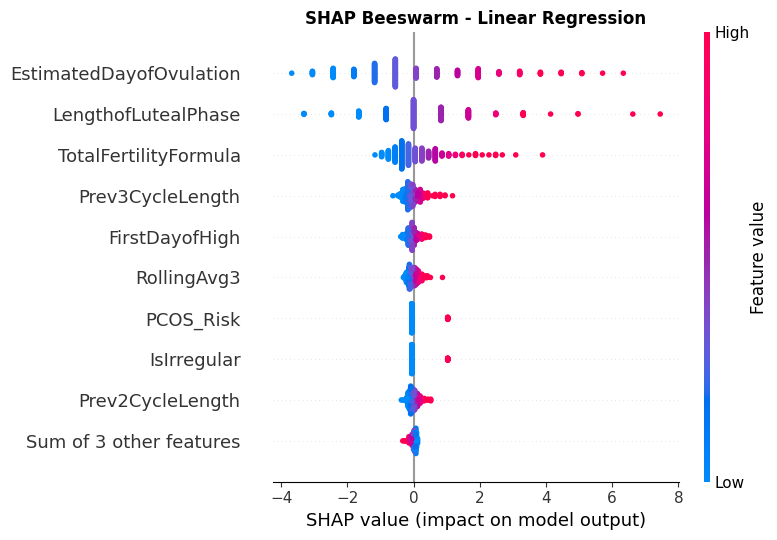

In [123]:
# SHAP for Linear Regression 
import shap
import matplotlib.pyplot as plt

lr_explainer = shap.LinearExplainer(lr_model, X_train)
lr_shap_values = lr_explainer.shap_values(X_test)

# Converting to SHAP Explanation object
lr_explanation = shap.Explanation(
    values=lr_shap_values,
    base_values=lr_explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

# Beeswarm
shap.plots.beeswarm(lr_explanation, max_display=10, show=False)
plt.title("SHAP Beeswarm - Linear Regression", fontweight='bold')
plt.tight_layout()
plt.show()


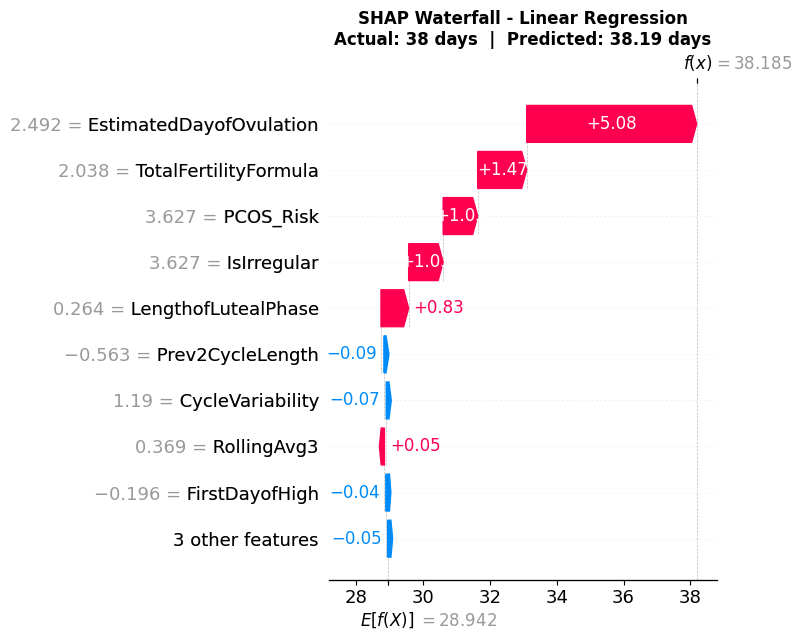

Actual:    38 days
Predicted: 38.19 days


In [124]:
# SHAP Waterfall for Linear Regression (Explains one single prediction in details)
sample_idx = 0

lr_explanation = shap.Explanation(
    values=lr_shap_values[sample_idx],
    base_values=lr_explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=feature_cols
)

shap.plots.waterfall(lr_explanation, show=False)
plt.title(f"SHAP Waterfall - Linear Regression\n"
          f"Actual: {y_test.iloc[sample_idx]:.0f} days  |  "
          f"Predicted: {lr_pred[sample_idx]:.2f} days",
          fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/shap_lr_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Actual:    {y_test.iloc[sample_idx]:.0f} days")
print(f"Predicted: {lr_pred[sample_idx]:.2f} days")


In [125]:
# Permutation Importance of Linear Regression
from sklearn.inspection import permutation_importance

lr_pi = permutation_importance(
    lr_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

lr_pi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': lr_pi.importances_mean,
    'Std': lr_pi.importances_std
}).sort_values('Importance', ascending=False)

print("Permutation Importance - Linear Regression:")
print(lr_pi_df.to_string(index=False))




Permutation Importance - Linear Regression:
                Feature  Importance      Std
EstimatedDayofOvulation    1.707528 0.091235
    LengthofLutealPhase    1.185152 0.064816
  TotalFertilityFormula    0.418389 0.043519
              PCOS_Risk    0.065332 0.014637
            IsIrregular    0.065332 0.014637
       Prev3CycleLength    0.046055 0.018206
         FirstDayofHigh    0.031430 0.012369
            RollingAvg3    0.019328 0.010583
       Prev2CycleLength    0.015421 0.010330
       CycleVariability    0.003189 0.003812
         LengthofMenses   -0.000033 0.000930
        PrevCycleLength   -0.000455 0.001419


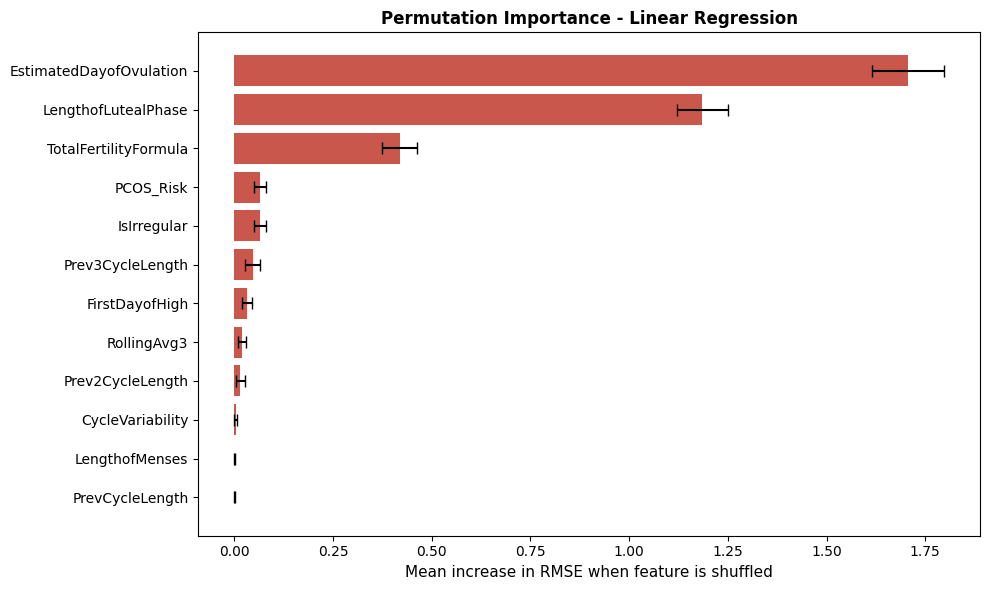

In [126]:
#visualizing Permutation Importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lr_pi_df['Feature'], lr_pi_df['Importance'],
        xerr=lr_pi_df['Std'], color='#c0392b', alpha=0.85, capsize=4)
ax.set_xlabel('Mean increase in RMSE when feature is shuffled', fontsize=11)
ax.set_title('Permutation Importance - Linear Regression', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/lr_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [127]:
# LIME (Local Interpretable Model-agnostic Explanations for LR) - unlike SHAP which gives global and local explanations, LIME focuses on explaining individual predictions by approximating the model locally with an interpretable model. It generates synthetic data around the instance being explained and fits a simple model (like linear regression) to understand feature contributions for that specific prediction.
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    mode='regression',
    random_state=42
)

sample_idx = 0
exp_lr = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=lr_model.predict,
    num_features=12
)

print("LIME - Linear Regression - Sample Explanation:")
print(f"Actual:          {y_test.iloc[sample_idx]:.0f} days")
print(f"Predicted:       {lr_pred[sample_idx]:.2f} days")
print(f"LIME local pred: {exp_lr.local_pred[0]:.2f} days")
print("\nFeature contributions:")
for feat, weight in exp_lr.as_list():
    print(f"  {feat:45s} {weight:+.4f}")




LIME - Linear Regression - Sample Explanation:
Actual:          38 days
Predicted:       38.19 days
LIME local pred: 36.16 days

Feature contributions:
  EstimatedDayofOvulation > 0.39                +4.6160
  TotalFertilityFormula > 0.34                  +1.5715
  IsIrregular > -0.28                           +1.1718
  PCOS_Risk > -0.28                             +0.9598
  -0.13 < LengthofLutealPhase <= 0.26           +0.5776
  Prev2CycleLength <= -0.56                     -0.2037
  CycleVariability > 0.44                       -0.1572
  -0.17 < RollingAvg3 <= 0.58                   +0.1445
  -0.54 < FirstDayofHigh <= -0.20               -0.1335
  -0.95 < LengthofMenses <= -0.11               -0.0741
  PrevCycleLength > 0.47                        -0.0395
  -0.32 < Prev3CycleLength <= 0.47              +0.0258


C:\Users\Maria\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


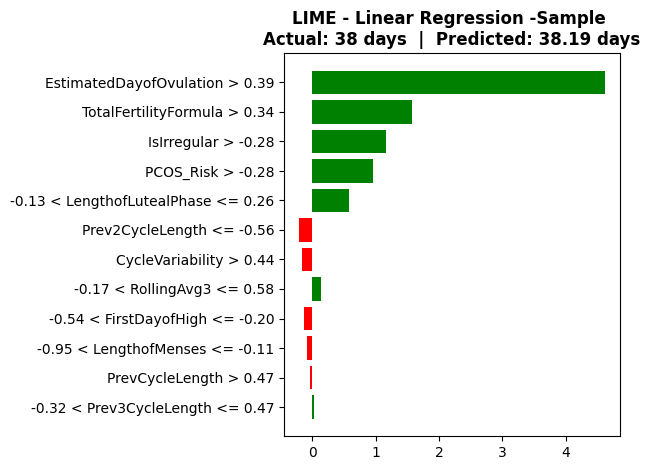

In [128]:
# Visualizing LIME explanation
fig = exp_lr.as_pyplot_figure()
plt.title(f"LIME - Linear Regression -Sample \n"
          f"Actual: {y_test.iloc[sample_idx]:.0f} days  |  "
          f"Predicted: {lr_pred[sample_idx]:.2f} days",
          fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/lime_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [129]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"MAE:  {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R2:   {rf_r2:.3f}")

Random Forest Results:
MAE:  0.674
RMSE: 1.823
R2:   0.738


In [146]:
# Cross-Validation for Random Forest
from sklearn.model_selection import cross_val_score
import numpy as np

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

print("Random Forest 5-Fold Cross-Validation")
for i, score in enumerate(rf_cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\nMean CV R²:       {rf_cv_scores.mean():.4f}")
print(f"Std Deviation:    {rf_cv_scores.std():.4f}")
print(f"Min R²:           {rf_cv_scores.min():.4f}")
print(f"Max R²:           {rf_cv_scores.max():.4f}")
print(f"\nTest Set R²:      {rf_r2:.4f}  (for comparison)")


Random Forest 5-Fold Cross-Validation
  Fold 1: R² = 0.7705
  Fold 2: R² = 0.8950
  Fold 3: R² = 0.8845
  Fold 4: R² = 0.8175
  Fold 5: R² = 0.9090

Mean CV R²:       0.8553
Std Deviation:    0.0528
Min R²:           0.7705
Max R²:           0.9090

Test Set R²:      0.7381  (for comparison)


In [144]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [131]:
# Random Forest Feature Importances
rf_fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importances:")
print(rf_fi_df.to_string(index=False))




Random Forest Feature Importances:
                Feature  Importance
EstimatedDayofOvulation    0.250725
              PCOS_Risk    0.201471
            IsIrregular    0.200584
    LengthofLutealPhase    0.134603
            RollingAvg3    0.110185
       Prev2CycleLength    0.029390
       CycleVariability    0.015125
  TotalFertilityFormula    0.015052
       Prev3CycleLength    0.013130
         FirstDayofHigh    0.012834
        PrevCycleLength    0.011219
         LengthofMenses    0.005682


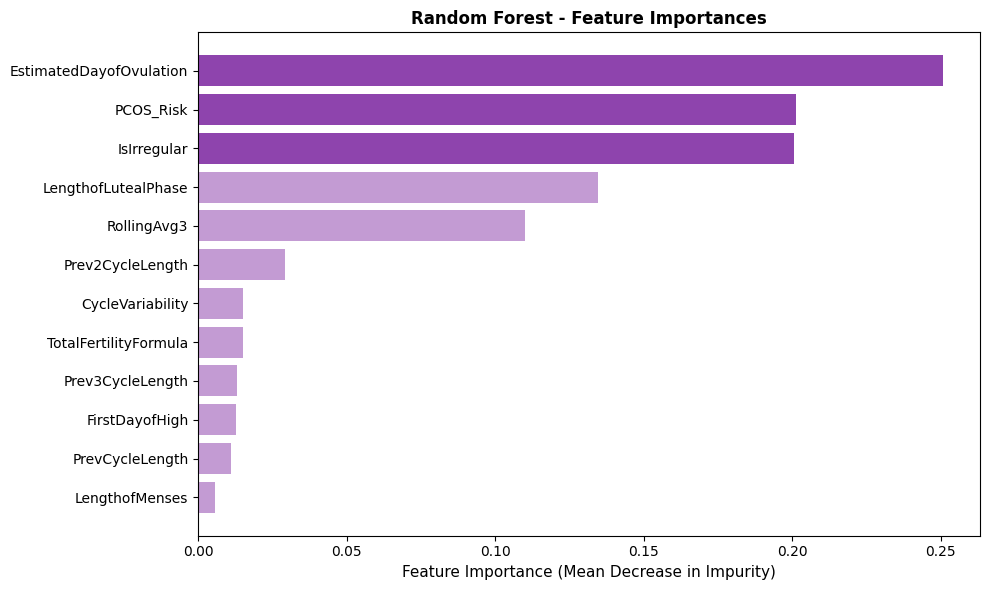

In [132]:
#Feature Importance Plot for Random Forest
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#8e44ad' if i < 3 else '#c39bd3' for i in range(len(rf_fi_df))]
ax.barh(rf_fi_df['Feature'], rf_fi_df['Importance'], color=colors)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest - Feature Importances', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

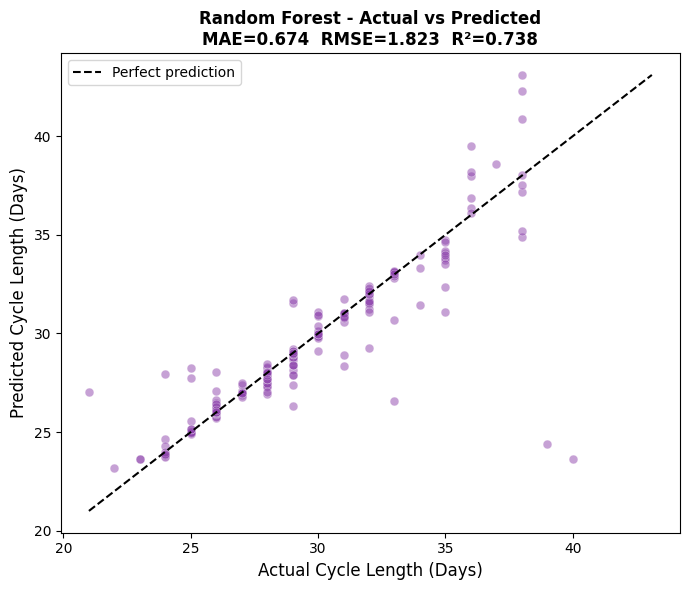

In [133]:
# RF Actual vs Predicted VALUE
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, rf_pred, alpha=0.5, color='#8e44ad',
           edgecolors='white', linewidth=0.4, s=40)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--',
        linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual Cycle Length (Days)', fontsize=12)
ax.set_ylabel('Predicted Cycle Length (Days)', fontsize=12)
ax.set_title(f'Random Forest - Actual vs Predicted\n'
             f'MAE={rf_mae:.3f}  RMSE={rf_rmse:.3f}  R²={rf_r2:.3f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('visuals/rf_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


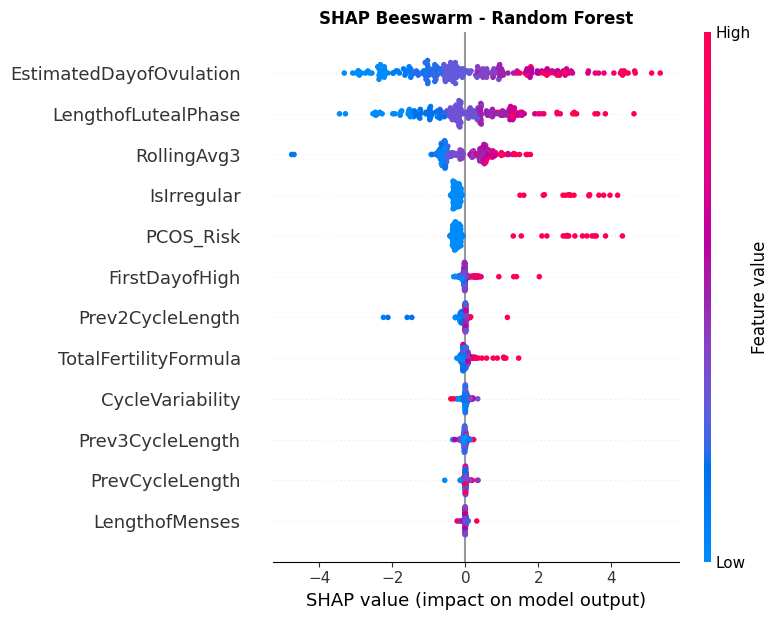

In [134]:
# SHAP for the Random Forest model
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

rf_explanation = shap.Explanation(
    values=rf_shap_values,
    base_values=rf_explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

# Beeswarm
shap.plots.beeswarm(rf_explanation, max_display=12, show=False)
plt.title("SHAP Beeswarm - Random Forest", fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/shap_rf_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


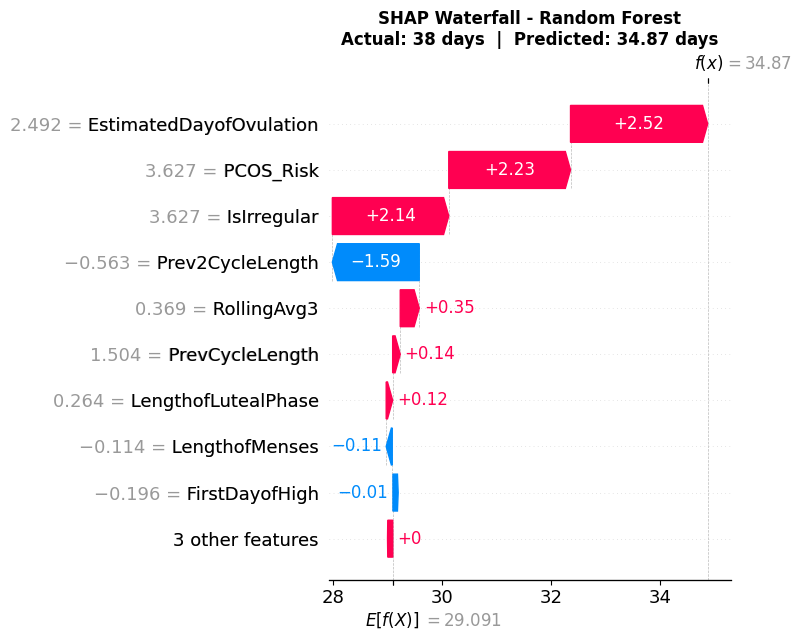

Actual:    38 days
Predicted: 34.87 days


In [135]:
# SHAP Waterfall - Random Forest (single prediction)
sample_idx = 0

rf_explanation_single = shap.Explanation(
    values=rf_shap_values[sample_idx],
    base_values=rf_explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=feature_cols
)

shap.plots.waterfall(rf_explanation_single, show=False)
plt.title(f"SHAP Waterfall - Random Forest\n"
          f"Actual: {y_test.iloc[sample_idx]:.0f} days  |  "
          f"Predicted: {rf_pred[sample_idx]:.2f} days",
          fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/shap_rf_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Actual:    {y_test.iloc[sample_idx]:.0f} days")
print(f"Predicted: {rf_pred[sample_idx]:.2f} days")


In [136]:
# Permutation Importance - Random Forest
rf_pi = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

rf_pi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_pi.importances_mean,
    'Std': rf_pi.importances_std
}).sort_values('Importance', ascending=False)

print("Permutation Importance - Random Forest:")
print(rf_pi_df.to_string(index=False))




Permutation Importance - Random Forest:
                Feature  Importance      Std
EstimatedDayofOvulation    1.905330 0.114784
    LengthofLutealPhase    0.940162 0.045517
  TotalFertilityFormula    0.127007 0.017804
         FirstDayofHigh    0.076558 0.034680
            RollingAvg3    0.020879 0.208626
       Prev3CycleLength    0.017495 0.024874
       CycleVariability    0.001498 0.015236
        PrevCycleLength   -0.023368 0.017010
              PCOS_Risk   -0.028264 0.051572
            IsIrregular   -0.031746 0.044940
         LengthofMenses   -0.033596 0.029693
       Prev2CycleLength   -0.221879 0.114922


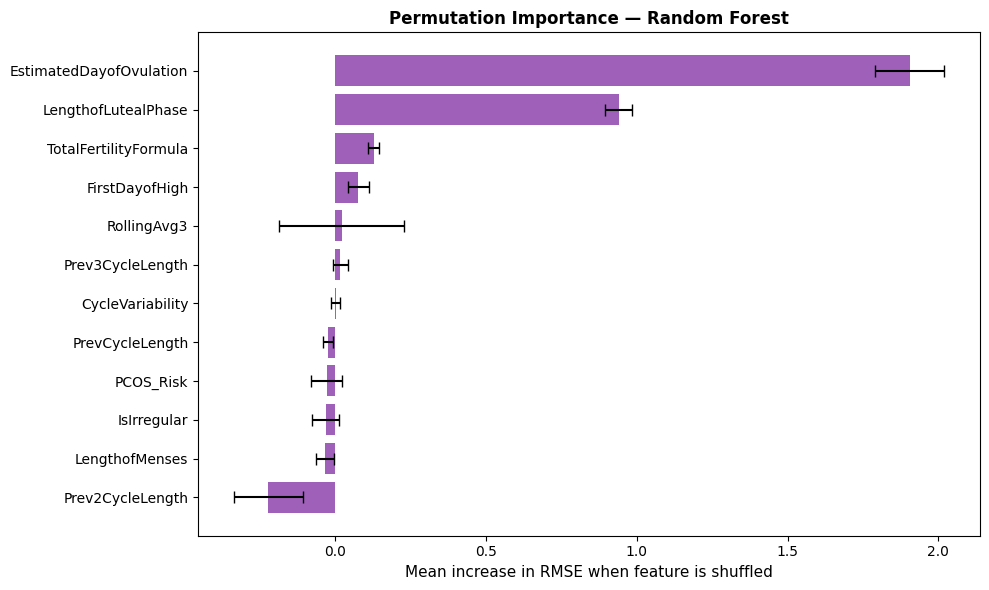

In [137]:
#Permutation Importance Plot for Random Forest
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_pi_df['Feature'], rf_pi_df['Importance'],
        xerr=rf_pi_df['Std'], color='#8e44ad', alpha=0.85, capsize=4)
ax.set_xlabel('Mean increase in RMSE when feature is shuffled', fontsize=11)
ax.set_title('Permutation Importance — Random Forest', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/rf_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [138]:
# LIME - Random Forest
sample_idx = 0
exp_rf = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=rf_model.predict,
    num_features=12
)

print("LIME - Random Forest(sample)")
print(f"Actual:          {y_test.iloc[sample_idx]:.0f} days")
print(f"Predicted:       {rf_pred[sample_idx]:.2f} days")
print(f"LIME local pred: {exp_rf.local_pred[0]:.2f} days")
print("\nFeature contributions:")
for feat, weight in exp_rf.as_list():
    print(f"  {feat:45s} {weight:+.4f}")



LIME - Random Forest(sample)
Actual:          38 days
Predicted:       34.87 days
LIME local pred: 37.46 days

Feature contributions:
  EstimatedDayofOvulation > 0.39                +4.7759
  IsIrregular > -0.28                           +2.0983
  PCOS_Risk > -0.28                             +1.9798
  -0.13 < LengthofLutealPhase <= 0.26           +0.7289
  -0.17 < RollingAvg3 <= 0.58                   +0.5864
  -0.54 < FirstDayofHigh <= -0.20               -0.2484
  Prev2CycleLength <= -0.56                     -0.2384
  TotalFertilityFormula > 0.34                  +0.2007
  CycleVariability > 0.44                       +0.0780
  -0.32 < Prev3CycleLength <= 0.47              -0.0495
  -0.95 < LengthofMenses <= -0.11               +0.0311
  PrevCycleLength > 0.47                        +0.0209


C:\Users\Maria\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


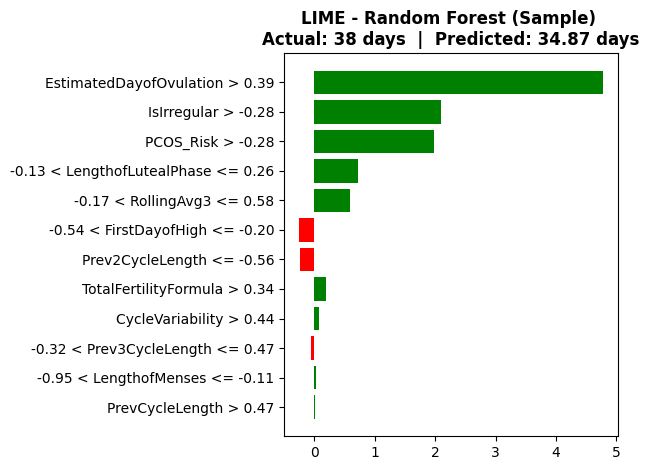

In [139]:
#LIME visualization for Random Forest
fig = exp_rf.as_pyplot_figure()
plt.title(f"LIME - Random Forest (Sample) \n"
          f"Actual: {y_test.iloc[sample_idx]:.0f} days  |  "
          f"Predicted: {rf_pred[sample_idx]:.2f} days",
          fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/lime_rf.png', dpi=150, bbox_inches='tight')
plt.show()


In [140]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
#Model Comparison
results = {
    'Linear Regression': {'MAE': 0.696, 'RMSE': 1.290, 'R2': 0.869},
    'Random Forest':     {'MAE': 0.674, 'RMSE': 1.823, 'R2': 0.738},
    # 'Gradient Boosting': {'MAE': 0.713, 'RMSE': 1.719, 'R2': 0.767}
   
}

results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df)
print("\nBest Model:", results_df['R2'].idxmax())

Model Comparison:
                     MAE   RMSE     R2
Linear Regression  0.696  1.290  0.869
Random Forest      0.674  1.823  0.738

Best Model: Linear Regression


In [ ]:
# # Saving the Final Model.
# import joblib

# # Our chosen model is Linear Regression
# final_model = lr_model

# joblib.dump(final_model, 'cycle_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')

# print("Final Model: Linear Regression")
# print("Model saved as cycle_model.pkl")
# print("Scaler saved as scaler.pkl")